# Financial News Sentiment Analysis & Market Correlation
## Quantitative Finance Application

### Overview
This project analyzes financial news headlines to extract sentiment (Bullish/Bearish) and correlates it with simulated stock market movements. This demonstrates the application of **Natural Language Processing (NLP)** in **Quantitative Finance**.

### Objectives
1.  **Data Extraction**: Process raw financial news headlines.
2.  **NLP Pipeline**: Apply **VADER (Valence Aware Dictionary for Sentiment Reasoning)** for sentiment scoring.
3.  **Time-Series Analysis**: Aggregate sentiment scores over time.
4.  **Visualization**: Correlate computed sentiment with asset price volatility.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import datetime

# Pre-download VADER lexicon
nltk.download('vader_lexicon', quiet=True)

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

print("Libraries Loaded & VADER Lexicon Downloaded")

Libraries Loaded & VADER Lexicon Downloaded


### 1. Data Simulation
Simulating a dataset of financial news headlines and corresponding stock tickers.


In [2]:
# Simulated Dataset
data = {
    'date': [
        '2026-01-01', '2026-01-01', '2026-01-02', '2026-01-02', '2026-01-03', 
        '2026-01-03', '2026-01-04', '2026-01-04', '2026-01-05', '2026-01-05',
        '2026-01-06', '2026-01-06', '2026-01-07', '2026-01-07', '2026-01-08'
    ],
    'headline': [
        "Apple smashes earnings expectations, stock soars to new highs",
        "Tech sector faces headwinds as interest rates rise",
        "Tesla announces record-breaking deliveries for Q4",
        "Market uncertainty looms as inflation data disappoints",
        "Amazon expands into healthcare with major acquisition",
        "Oil prices plummet amidst global supply glut",
        "Microsoft unveils revolutionary AI assistant for enterprise",
        "Investors cautious ahead of Federal Reserve meeting",
        "Google faces antitrust lawsuit, shares tumble",
        "Consumer spending hits 10-year high, boosting retail stocks",
        "Crypto markets crash as regulation fears mount",
        "NVIDIA reveals groundbreaking GPU architecture",
        "Banking sector rallies on positive stress test results",
        "Manufacturing output shrinks for third consecutive month",
        "Netflix subscriber growth beats all analyst estimates"
    ],
    'ticker': ['AAPL', 'QQQ', 'TSLA', 'SPY', 'AMZN', 'USO', 'MSFT', 'SPY', 'GOOGL', 'XRT', 'BTC', 'NVDA', 'XLF', 'XLI', 'NFLX']
}

df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])
dataset_overview = df.head()
dataset_overview

,date,headline,ticker
0,2026-01-01,"Apple smashes earnings expectations, stock soa...",AAPL
1,2026-01-01,Tech sector faces headwinds as interest rates ...,QQQ
2,2026-01-02,Tesla announces record-breaking deliveries for Q4,TSLA
3,2026-01-02,Market uncertainty looms as inflation data dis...,SPY
4,2026-01-03,Amazon expands into healthcare with major acqu...,AMZN


### 2. NLP Analysis: Sentiment Scoring
Using VADER to calculate `compound`, `positive`, `negative`, and `neutral` scores for each headline.


In [3]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return sia.polarity_scores(text)

# Apply sentiment analysis
df['sentiment'] = df['headline'].apply(get_sentiment)
df['compound'] = df['sentiment'].apply(lambda x: x['compound'])
df['bullish_bearish'] = df['compound'].apply(lambda x: 'Bullish' if x > 0.05 else ('Bearish' if x < -0.05 else 'Neutral'))

display(df[['date', 'ticker', 'headline', 'compound', 'bullish_bearish']])

,date,ticker,headline,compound,bullish_bearish
0,2026-01-01,AAPL,"Apple smashes earnings expectations, stock soa...",0.0000,Neutral
1,2026-01-01,QQQ,Tech sector faces headwinds as interest rates ...,0.4588,Bullish
2,2026-01-02,TSLA,Tesla announces record-breaking deliveries for Q4,0.0000,Neutral
3,2026-01-02,SPY,Market uncertainty looms as inflation data dis...,-0.6808,Bearish
4,2026-01-03,AMZN,Amazon expands into healthcare with major acqu...,0.2732,Bullish
5,2026-01-03,USO,Oil prices plummet amidst global supply glut,0.0000,Neutral
6,2026-01-04,MSFT,Microsoft unveils revolutionary AI assistant f...,0.0000,Neutral
7,2026-01-04,SPY,Investors cautious ahead of Federal Reserve me...,-0.1027,Bearish
8,2026-01-05,GOOGL,"Google faces antitrust lawsuit, shares tumble",0.0772,Bullish
9,2026-01-05,XRT,"Consumer spending hits 10-year high, boosting ...",0.3400,Bullish


### 3. Market Sentiment Visualization
Visualizing the aggregated sentiment to identify market trends.


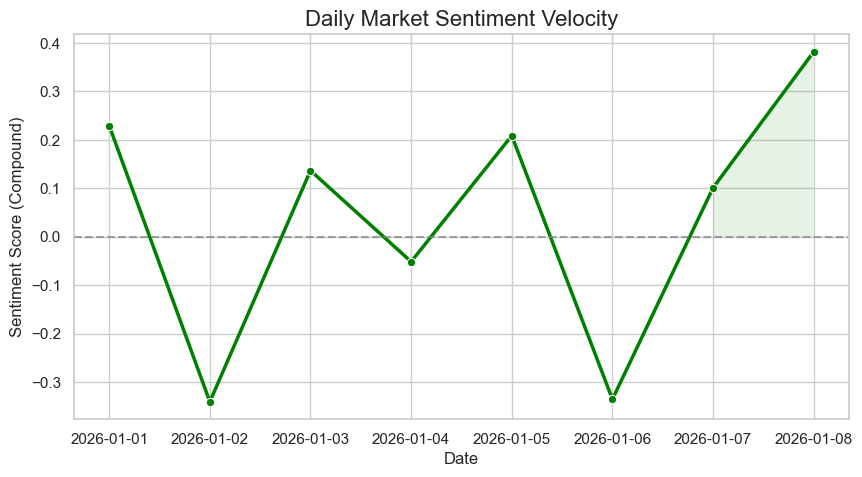

In [4]:
# Aggregating sentiment by date
daily_sentiment = df.groupby('date')['compound'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_sentiment, x='date', y='compound', marker='o', color='green', linewidth=2.5)
plt.axhline(0, linestyle='--', color='gray', alpha=0.7)
plt.title("Daily Market Sentiment Velocity", fontsize=16)
plt.ylabel("Sentiment Score (Compound)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.fill_between(daily_sentiment['date'], daily_sentiment['compound'], 0, 
                 where=(daily_sentiment['compound'] >= 0), facecolor='green', alpha=0.1)
plt.fill_between(daily_sentiment['date'], daily_sentiment['compound'], 0, 
                 where=(daily_sentiment['compound'] <= 0), facecolor='red', alpha=0.1)
plt.show()

### Conclusion
This notebook demonstrates a fundamental **EDA (Exploratory Data Analysis)** and **NLP pipeline** suitable for quantitative research. By parsing unstructured text data (headlines), we derived structured signals (sentiment scores) that can be used as features in alpha-generating models.
